In [ ]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse
print("Libraries loaded!")

Libraries loaded!


In [ ]:
# Load datasets
df_reddit = pd.read_csv('posts.csv')
df_clickbait = pd.read_csv('clickbait_data.csv')

print("Reddit dataset:", df_reddit.shape)
print("Clickbait dataset:", df_clickbait.shape)

Reddit dataset: (109992, 11)
Clickbait dataset: (32000, 2)


In [ ]:
# Data Cleaning
# 1. Check missing values
print("=== MISSING VALUES (Reddit) ===")
print(df_reddit.isnull().sum())

print("\n=== MISSING VALUES (Clickbait) ===")
print(df_clickbait.isnull().sum())

=== MISSING VALUES (Reddit) ===
post_id              0
subreddit            0
title                0
body            105077
author               0
created_utc          0
score                0
upvote_ratio         0
num_comments         0
url               4804
permalink            0
dtype: int64

=== MISSING VALUES (Clickbait) ===
headline     0
clickbait    0
dtype: int64


In [ ]:
# Data Cleaning

# 1. Drop rows with missing URLs
df_reddit = df_reddit.dropna(subset=['url'])

# 2. Filter out Reddit internal links (keep only external news sources)
df_reddit = df_reddit[~df_reddit['url'].str.contains('reddit.com', na=False)]

# 3. Drop rows with missing titles (precautionary - no missing titles found above)
df_reddit = df_reddit.dropna(subset=['title'])

print("Reddit dataset after cleaning:", df_reddit.shape)
print("Removed rows:", 109992 - df_reddit.shape[0])

Reddit dataset after cleaning: (104030, 11)
Removed rows: 5962


In [ ]:
# Top 200 most shared domains in the Reddit dataset were examined
# Each domain was manually verified on Media Bias/Fact Check
# Categorized as Reliable / Unreliable / Non-news

df_reddit['domain'] = df_reddit['url'].apply(
    lambda x: urlparse(x).netloc.replace('www.', '')
)

pd.set_option('display.max_rows', 200)
print(df_reddit['domain'].value_counts().head(200))

domain
reuters.com                      7586
bbc.com                          4991
theguardian.com                  4880
youtube.com                      3900
apnews.com                       3466
youtu.be                         2676
aicentral.site                   2324
kyivindependent.com              2009
cnn.com                          1783
nytimes.com                      1383
pravda.com.ua                    1318
timesofisrael.com                1237
politico.eu                      1224
bloomberg.com                    1203
nbcnews.com                      1155
bbc.co.uk                        1153
edition.cnn.com                  1145
cbc.ca                           1109
newsweek.com                     1101
jpost.com                        1088
aljazeera.com                    1066
news.sky.com                     1051
euronews.com                      817
ctvnews.ca                        810
abc.net.au                        750
cnbc.com                          703
indep

In [ ]:
# Top 200 most shared domains in the Reddit dataset were examined
# Each domain was manually verified on Media Bias/Fact Check
# Categorized as Reliable / Unreliable / Non-news

reliable = [
    'reuters.com', 'bbc.com', 'bbc.co.uk', 'theguardian.com',
    'apnews.com', 'nytimes.com', 'bloomberg.com', 'nbcnews.com',
    'cnn.com', 'edition.cnn.com', 'cbc.ca', 'newsweek.com',
    'politico.eu', 'kyivindependent.com', 'aljazeera.com',
    'news.sky.com', 'euronews.com', 'ctvnews.ca', 'abc.net.au',
    'cnbc.com', 'independent.co.uk', 'cbsnews.com', 'telegraph.co.uk',
    'france24.com', 'dw.com', 'abcnews.go.com', 'washingtonpost.com',
    'thehill.com', 'scmp.com', 'swissinfo.ch',
    'timesofindia.indiatimes.com', 'thehindu.com', 'ndtv.com',
    'hindustantimes.com', 'wsj.com', 'axios.com', 'ft.com',
    'npr.org', 'politico.com', 'lemonde.fr', 'globalnews.ca',
    'straitstimes.com', 'notesfrompoland.com', 'theglobeandmail.com',
    'rfi.fr', 'businessinsider.com', 'forbes.com', 'nationalpost.com',
    'usatoday.com', 'channelnewsasia.com', 'time.com', 'rferl.org',
    'pbs.org', 'thetimes.com', 'haaretz.com'
]

unreliable = [
    'jpost.com', 'timesofisrael.com', 'nypost.com',
    'dailymail.co.uk', 'foxnews.com', 'breitbart.com',
    'rt.com', 'sputniknews.com', 'pravda.com.ua',
    'euromaidanpress.com', 'united24media.com',
    'kyivpost.com', 'themoscowtimes.com', 'ynetnews.com',
    'middleeasteye.net', 'thedailybeast.com',
    'wanfar.com', 'expose-news.com', 'wionews.com',
    'iranintl.com', 'aa.com.tr', 'gwaramedia.com',
    'newsukraine.rbc.ua', 'unn.ua', 'global.espreso.tv',
    'english.nv.ua', 'israelhayom.com', 'turkiyetoday.com',
    'irannewswire.org', 'express.co.uk', 'timesnownews.com',
    'english.alarabiya.net',
    'newarab.com', 'militarnyi.com', 'theprint.in',
    'novayagazeta.eu', 'tvpworld.com'
]

filter_domains = [
    'youtube.com', 'youtu.be', 'aicentral.site',
    'yahoo.com', 'msn.com', 'x.com', 'instagram.com',
    'google.com', 'facebook.com', 'medium.com', 'threads.com',
    'finance.yahoo.com', 'l.smartnews.com', 'share.google',
    'gofund.me', 'chng.it', 'tiktok.com', 't.me',
    'c.org', 'uk.news.yahoo.com', 'm.jpost.com',
    'amp.cnn.com', 'people.com'
]

# Remove filter domains
df_reddit = df_reddit[~df_reddit['domain'].isin(filter_domains)]

# Add reliability score
def get_reliability(domain):
    if domain in reliable:
        return 1
    elif domain in unreliable:
        return 0
    else:
        return None

df_reddit['source_reliable'] = df_reddit['domain'].apply(get_reliability)

# Keep only labeled posts
df_labeled = df_reddit.dropna(subset=['source_reliable'])

print("Total labeled posts:", df_labeled.shape[0])
print("Reliable:", (df_labeled['source_reliable'] == 1).sum())
print("Unreliable:", (df_labeled['source_reliable'] == 0).sum())

Total labeled posts: 61807
Reliable: 51628
Unreliable: 10179


### Clickbait Classification Approach

In this project, a logistic regression model was trained on a labeled clickbait dataset to classify headlines as clickbait or non-clickbait.

The purpose of this model is not the main focus of the project, but rather to serve as a tool for labeling Reddit post titles. These predicted labels are then used in the subsequent exploratory data analysis and hypothesis testing to examine the relationship between clickbait headlines and user engagement.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Prepare clickbait dataset
X = df_clickbait['headline']
y = df_clickbait['clickbait']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert text to numerical data using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Evaluate the model
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.96390625

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      3127
           1       0.98      0.95      0.96      3273

    accuracy                           0.96      6400
   macro avg       0.96      0.96      0.96      6400
weighted avg       0.96      0.96      0.96      6400



In [ ]:
# Apply clickbait classifier to Reddit post titles
reddit_tfidf = vectorizer.transform(df_labeled['title'])
df_labeled = df_labeled.copy()
df_labeled['clickbait'] = model.predict(reddit_tfidf)

print("Clickbait distribution:")
print(df_labeled['clickbait'].value_counts())
print("\nClickbait ratio:", df_labeled['clickbait'].mean().round(3))

Clickbait distribution:
clickbait
0    58735
1     3072
Name: count, dtype: int64

Clickbait ratio: 0.05


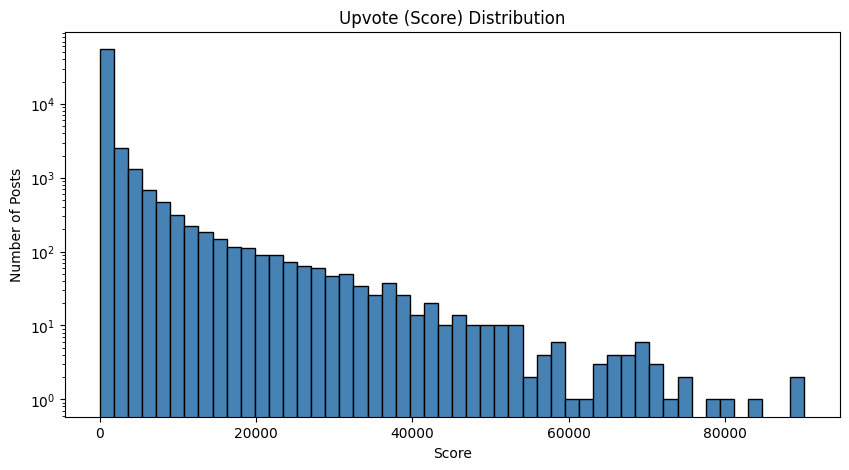

In [ ]:
# EDA - Upvote (Score) Distribution
plt.figure(figsize=(10,5))
plt.hist(df_labeled['score'], bins=50, color='steelblue', edgecolor='black')
plt.title('Upvote (Score) Distribution')
plt.xlabel('Score')
plt.ylabel('Number of Posts')
plt.yscale('log')
plt.show()


## Upvote Distribution

However, the distribution of Reddit post scores shows high right skewness. Many Reddit posts have low score values, but a few posts generate high score values and thus are considered outliers. This shows that Reddit post scores do not follow a normal distribution, making it appropriate to conduct non-parametric tests.

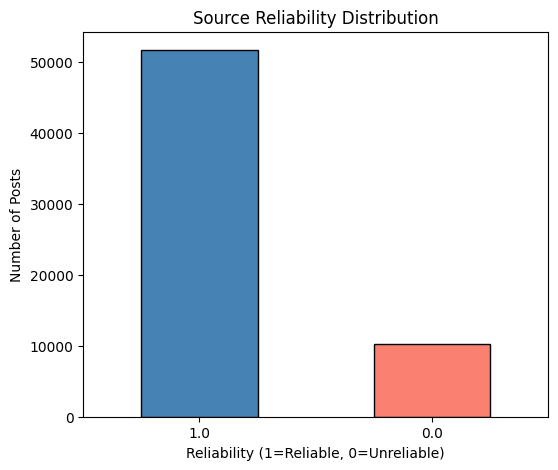

In [ ]:
# EDA - Source Reliability Distribution
plt.figure(figsize=(6,5))
df_labeled['source_reliable'].value_counts().plot(
    kind='bar',
    color=['steelblue', 'salmon'],
    edgecolor='black'
)
plt.title('Source Reliability Distribution')
plt.xlabel('Reliability (1=Reliable, 0=Unreliable)')
plt.ylabel('Number of Posts')
plt.xticks(rotation=0)
plt.show()

### Interpretation of Source Reliability Distribution

Most labeled posts in the dataset come from reliable news sources, while a smaller portion comes from unreliable sources. This suggests that the Reddit worldnews dataset is dominated by mainstream or generally trusted outlets. Therefore, comparisons involving unreliable sources should be interpreted with this imbalance in mind.

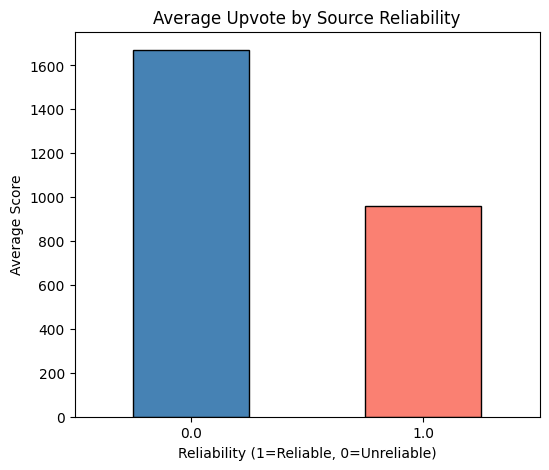

In [ ]:
# EDA - Average Upvote by Source Reliability
plt.figure(figsize=(6,5))
df_labeled.groupby('source_reliable')['score'].mean().plot(
    kind='bar',
    color=['steelblue', 'salmon'],
    edgecolor='black'
)
plt.title('Average Upvote by Source Reliability')
plt.xlabel('Reliability (1=Reliable, 0=Unreliable)')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.show()

### Interpretation of Average Upvote by Source Reliability

This graph compares the average score of posts shared from reliable
and unreliable news sources. Surprisingly, posts from unreliable sources
received a higher average upvote score than posts from reliable sources.
This may suggest that sensational or provocative content from unreliable
sources tends to attract more user attention on Reddit.

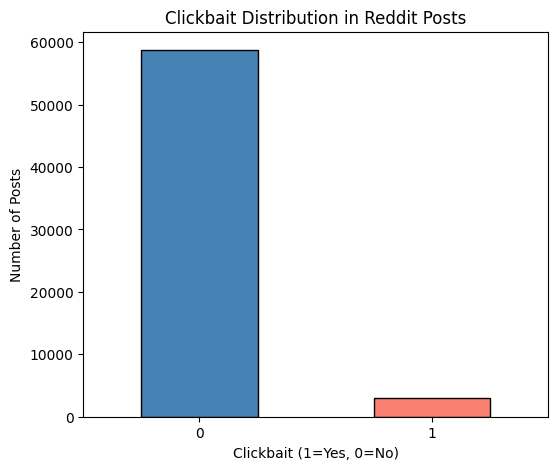

In [ ]:
# EDA - Clickbait Distribution in Reddit Posts
plt.figure(figsize=(6,5))
df_labeled['clickbait'].value_counts().plot(
    kind='bar',
    color=['steelblue', 'salmon'],
    edgecolor='black'
)
plt.title('Clickbait Distribution in Reddit Posts')
plt.xlabel('Clickbait (1=Yes, 0=No)')
plt.ylabel('Number of Posts')
plt.xticks(rotation=0)
plt.show()

### Interpretation of Clickbait Distribution

Only a small proportion of Reddit posts are classified as clickbait. This suggests that most posts in the dataset use relatively neutral or informative headlines rather than strongly attention-grabbing ones. Even though clickbait posts are less common, they may still have a measurable effect on engagement, which is explored in the next analyses.

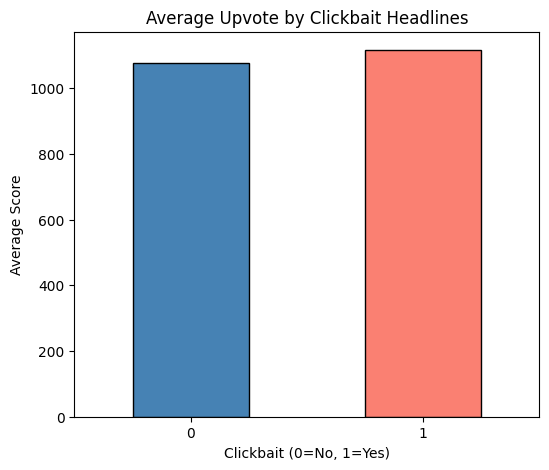

clickbait
0    1076.672069
1    1116.286133
Name: score, dtype: float64


In [ ]:
# EDA - Average Upvote by Clickbait
plt.figure(figsize=(6,5))
df_labeled.groupby('clickbait')['score'].mean().plot(
    kind='bar',
    color=['steelblue', 'salmon'],
    edgecolor='black'
)
plt.title('Average Upvote by Clickbait Headlines')
plt.xlabel('Clickbait (0=No, 1=Yes)')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.show()

# Numerical summary
print(df_labeled.groupby('clickbait')['score'].mean())

### Interpretation of Average Upvote by Clickbait

The average score of clickbait posts is slightly higher than that of non-clickbait posts. This provides initial evidence that clickbait-style headlines may attract more user attention and generate more upvotes. However, this difference should be interpreted carefully and confirmed with statistical testing rather than relying only on visual comparison.

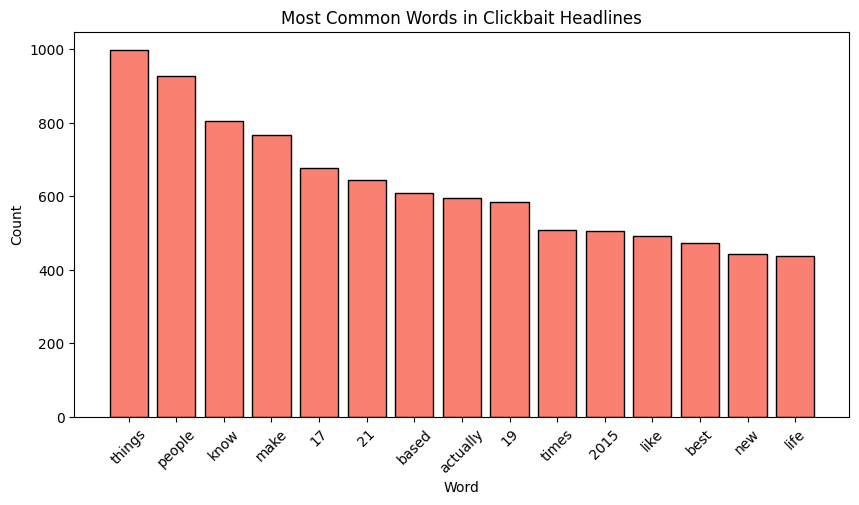

In [ ]:
# EDA - Most Common Words in Clickbait Headlines
from sklearn.feature_extraction.text import CountVectorizer

# Separate clickbait and non-clickbait headlines
clickbait_titles = df_clickbait[df_clickbait['clickbait'] == 1]['headline']
non_clickbait_titles = df_clickbait[df_clickbait['clickbait'] == 0]['headline']

# Top 15 most common words
vectorizer_eda = CountVectorizer(max_features=15, stop_words='english')

# Clickbait words
clickbait_matrix = vectorizer_eda.fit_transform(clickbait_titles)
clickbait_words = pd.DataFrame({
    'word': vectorizer_eda.get_feature_names_out(),
    'count': clickbait_matrix.toarray().sum(axis=0)
}).sort_values('count', ascending=False)

plt.figure(figsize=(10,5))
plt.bar(clickbait_words['word'], clickbait_words['count'], color='salmon', edgecolor='black')
plt.title('Most Common Words in Clickbait Headlines')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Interpretation of Common Words in Clickbait Headlines

Many of these words appear to be sensational or curiosity-driven, which is consistent with the general definition of clickbait.

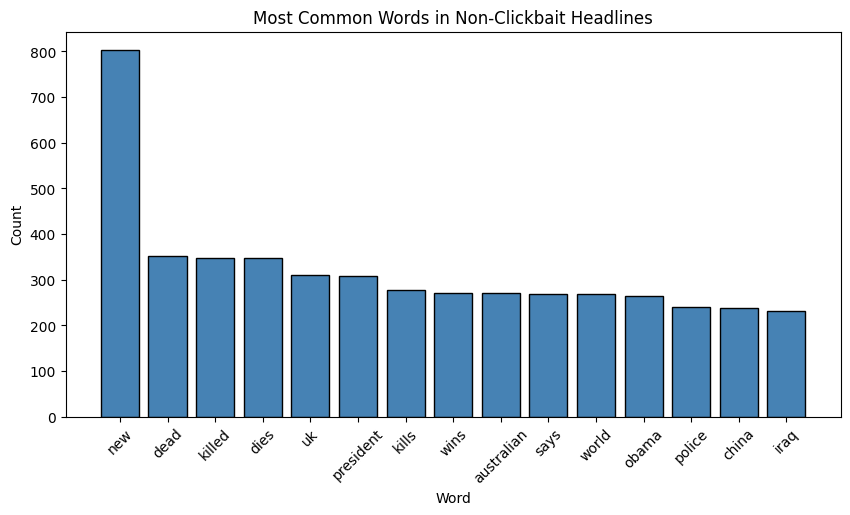

In [ ]:
# EDA - Most Common Words in Non-Clickbait Headlines
vectorizer_eda2 = CountVectorizer(max_features=15, stop_words='english')
non_clickbait_matrix = vectorizer_eda2.fit_transform(non_clickbait_titles)
non_clickbait_words = pd.DataFrame({
    'word': vectorizer_eda2.get_feature_names_out(),
    'count': non_clickbait_matrix.toarray().sum(axis=0)
}).sort_values('count', ascending=False)

plt.figure(figsize=(10,5))
plt.bar(non_clickbait_words['word'], non_clickbait_words['count'], color='steelblue', edgecolor='black')
plt.title('Most Common Words in Non-Clickbait Headlines')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Interpretation of Common Words in Non-Clickbait Headlines

Unlike clickbait, non-clickbait headlines include more neutral and factual words, which indicates that non-clickbait news articles are usually more informative rather than sensational. It can be seen that there is a difference in word distribution between the two types of headlines, which proves the legitimacy of using the classification method in this project.

In [ ]:
from scipy import stats

# Hypothesis 1:
# H0: There is no difference in upvote scores between clickbait and non-clickbait headlines.
# H1: There is a difference in upvote scores between clickbait and non-clickbait headlines.

# Separate clickbait and non-clickbait groups
clickbait_scores = df_labeled[df_labeled['clickbait'] == 1]['score']
non_clickbait_scores = df_labeled[df_labeled['clickbait'] == 0]['score']

# Two-sided Mann-Whitney U Test (used because score is not normally distributed)
stat, p_value = stats.mannwhitneyu(
    clickbait_scores,
    non_clickbait_scores,
    alternative='two-sided'
)

print("Mann-Whitney U Test (Two-Sided):")
print(f"Clickbait average score: {clickbait_scores.mean():.2f}")
print(f"Non-clickbait average score: {non_clickbait_scores.mean():.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Difference is statistically significant! H0 rejected.")
else:
    print("❌ Difference is not statistically significant. H0 not rejected.")

Mann-Whitney U Test (Two-Sided):
Clickbait average score: 1116.29
Non-clickbait average score: 1076.67
P-value: 0.0000
✅ Difference is statistically significant! H0 rejected.


### Interpretation of Hypothesis Test 1

The Mann-Whitney U test shows a statistically significant difference in upvote scores between clickbait and non-clickbait posts (p < 0.05). In addition, clickbait posts have a slightly higher average score than non-clickbait posts. This suggests that clickbait headlines are associated with greater Reddit engagement in terms of upvotes.

In [ ]:
from scipy import stats
from scipy.stats import chi2_contingency

# Hypothesis 2:
# H0: Unreliable news sources do not use more clickbait headlines than reliable sources.
# H1: Unreliable news sources use more clickbait headlines than reliable sources.

# Clickbait ratio by source reliability
reliable_clickbait = df_labeled[df_labeled['source_reliable'] == 1]['clickbait'].mean()
unreliable_clickbait = df_labeled[df_labeled['source_reliable'] == 0]['clickbait'].mean()

print(f"Clickbait ratio in reliable sources: {reliable_clickbait:.3f}")
print(f"Clickbait ratio in unreliable sources: {unreliable_clickbait:.3f}")

# Chi-square test
contingency_table = pd.crosstab(df_labeled['source_reliable'], df_labeled['clickbait'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square Test P-value: {p_value:.4f}")
if p_value < 0.05:
    print("✅ Unreliable sources use significantly more clickbait! H0 rejected.")
else:
    print("❌ No significant difference. H0 not rejected.")

Clickbait ratio in reliable sources: 0.050
Clickbait ratio in unreliable sources: 0.048

Chi-square Test P-value: 0.5352
❌ No significant difference. H0 not rejected.


### Interpretation of Hypothesis Test 2

The clickbait ratio is very similar for reliable and unreliable news sources, and the chi-square test result is not statistically significant (p > 0.05). Therefore, the null hypothesis cannot be rejected. This suggests that, in this dataset, unreliable sources do not use clickbait headlines more frequently than reliable sources.

In [ ]:
# Hypothesis 3:
# H0: There is no difference in the number of comments between clickbait and non-clickbait headlines.
# H1: There is a difference in the number of comments between clickbait and non-clickbait headlines.

# Separate clickbait and non-clickbait groups
clickbait_comments = df_labeled[df_labeled['clickbait'] == 1]['num_comments']
non_clickbait_comments = df_labeled[df_labeled['clickbait'] == 0]['num_comments']

# Two-sided Mann-Whitney U Test
stat, p_value = stats.mannwhitneyu(
    clickbait_comments,
    non_clickbait_comments,
    alternative='two-sided'
)

print("Clickbait average comments:", clickbait_comments.mean().round(2))
print("Non-clickbait average comments:", non_clickbait_comments.mean().round(2))
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Difference is statistically significant! H0 rejected.")
    print("Note: Non-clickbait posts receive more comments.")
else:
    print("❌ Difference is not statistically significant. H0 not rejected.")

Clickbait average comments: 80.15
Non-clickbait average comments: 81.18
P-value: 0.0000
✅ Difference is statistically significant! H0 rejected.
Note: Non-clickbait posts receive more comments.


### Interpretation of Hypothesis Test 3

The Mann-Whitney U test indicates a statistically significant difference in the
number of comments between clickbait and non-clickbait posts (p < 0.05).
Interestingly, non-clickbait posts received slightly more comments on average.
This suggests that while clickbait may attract upvotes, it does not drive
more discussion — in fact, more straightforward headlines appear to generate
greater comment activity.

In [ ]:
# Save the final dataset
df_labeled.to_csv('reddit_final.csv', index=False)
print("Dataset saved successfully!")

Dataset saved successfully!
